In [7]:
!pip install numpy

In [8]:
import numpy as np

def relu(x):
    return x * (x > 0)

def relu2deriv(x):
    return (x > 0)

np.random.seed(1)

# Input
streetlights = np.array( [[ 1, 0, 1 ],
                          [ 0, 1, 1 ],
                          [ 0, 0, 1 ],
                          [ 1, 1, 1 ] ] )

# Goal Predictions
walk_vs_stop = np.array([[ 1, 1, 0, 0]]).T

alpha = 0.2

# Hidden layer Nodes
hidden_size = 4

# 3 x 4 matrix : -1.0 ~ 1.0
weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
print(f"weights_0_1{weights_0_1.shape,type(weights_0_1)}=\n" + str(weights_0_1))
# 4 x 1 matrix : -1.0 ~ 1.0
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1
print(f"weights_1_2{weights_1_2.shape,type(weights_1_2)}=\n" + str(weights_1_2))

for iteration in range(1):
    #print(f"iteration={iteration}")
    output_error = 0
    for i in range(len(streetlights)):
        print(f"streetlight={i}")
        # Forward Propagation
        input_layer = streetlights[i]
        goal_pred = walk_vs_stop[i]

        ### input -> hidden
        # 1x3 * 3x4 matrix -> 1x4 matrix
        hidden_layer = relu(np.dot(input_layer, weights_0_1))
        print(f"hidden_layer{hidden_layer.shape,type(hidden_layer)}=" + str(hidden_layer))

        ### hidden -> output
        # 1x4 * 4x1 matrix -> 1x1 matrixa
        output_layer = np.dot(hidden_layer, weights_1_2)
        print(f"output_layer{output_layer.shape,type(output_layer)}=" + str(output_layer))

        # ------------------------------
        # Backpropagation
        error = (output_layer - goal_pred) ** 2
        output_error += error

        # delta for output layer
        output_delta = output_layer - goal_pred
        print(f"output_delta{output_delta.shape,type(output_delta)}=" + str(output_delta))

        # delta for hidden layer
        # 1x1 matrix * 1x4 matrix -> 1x4 matrix
        hidden_delta = output_delta.dot(weights_1_2.T) * relu2deriv(hidden_layer)
        print(f"hidden_delta{hidden_delta.shape,type(hidden_delta)}=" + str(hidden_delta))

        derivative_1_2 = np.outer(hidden_layer.T,output_delta)
        print(f"derivative_1_2{derivative_1_2.shape,type(derivative_1_2)}=\n" + str(derivative_1_2))

        derivative_0_1 = np.outer(input_layer.T, hidden_delta)
        print(f"derivative_0_1{derivative_0_1.shape,type(derivative_0_1)}=\n" + str(derivative_0_1))

        # w = w - alpha * ( input * delta )
        weights_1_2 = weights_1_2 - alpha * derivative_1_2
        print(f"weights_1_2{weights_1_2.shape,type(weights_1_2)}=\n" + str(weights_1_2))

        weights_0_1 = weights_0_1 - alpha * derivative_0_1
        print(f"weights_0_1{weights_0_1.shape,type(weights_0_1)}=\n" + str(weights_0_1))

        if(iteration % 10 == 9):
            print(f"Error{iteration}:" + str(output_error))

weights_0_1((3, 4), <class 'numpy.ndarray'>)=
[[-0.16595599  0.44064899 -0.99977125 -0.39533485]
 [-0.70648822 -0.81532281 -0.62747958 -0.30887855]
 [-0.20646505  0.07763347 -0.16161097  0.370439  ]]
weights_1_2((4, 1), <class 'numpy.ndarray'>)=
[[-0.5910955 ]
 [ 0.75623487]
 [-0.94522481]
 [ 0.34093502]]
streetlight=0
hidden_layer((4,), <class 'numpy.ndarray'>)=[-0.          0.51828245 -0.         -0.        ]
output_layer((1,), <class 'numpy.ndarray'>)=[0.39194327]
output_delta((1,), <class 'numpy.ndarray'>)=[-0.60805673]
hidden_delta((4,), <class 'numpy.ndarray'>)=[ 0.         -0.45983371  0.         -0.        ]
derivative_1_2((4, 1), <class 'numpy.ndarray'>)=
[[ 0.        ]
 [-0.31514514]
 [ 0.        ]
 [ 0.        ]]
derivative_0_1((3, 4), <class 'numpy.ndarray'>)=
[[ 0.         -0.45983371  0.         -0.        ]
 [ 0.         -0.          0.         -0.        ]
 [ 0.         -0.45983371  0.         -0.        ]]
weights_1_2((4, 1), <class 'numpy.ndarray'>)=
[[-0.5910955 ]
 [

w01((3, 4), <class 'numpy.ndarray'>)=
[[-0.16595599  0.44064899 -0.99977125 -0.39533485]
 [-0.70648822 -0.81532281 -0.62747958 -0.30887855]
 [-0.20646505  0.07763347 -0.16161097  0.370439  ]]
w12((4, 1), <class 'numpy.ndarray'>)=
[[-0.5910955 ]
 [ 0.75623487]
 [-0.94522481]
 [ 0.34093502]]


/Users/daisuke.inoue/.pyenv/versions/3.13.2/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/daisuke.inoue/.pyenv/versions/3.13.2/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/daisuke.inoue/.pyenv/versions/3.13.2/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


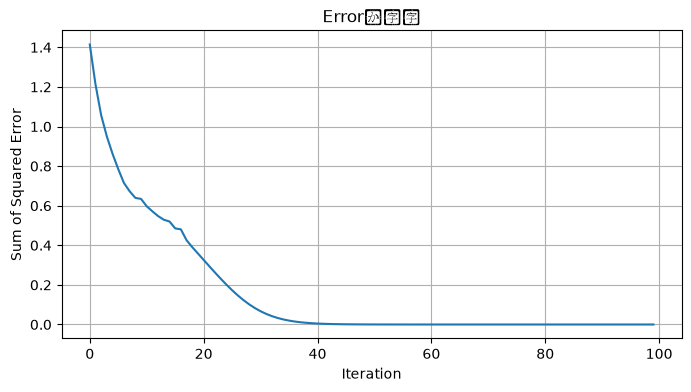

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)

iterations = 100
error_history = []
hidden_size = 4
# Input
streetlights = np.array( [[ 1, 0, 1 ],
                          [ 0, 1, 1 ],
                          [ 0, 0, 1 ],
                          [ 1, 1, 1 ] ] )

# Goal Predictions
walk_vs_stop = np.array([[ 1, 1, 0, 0]]).T
# 3 x 4 matrix : -1.0 ~ 1.0
w01 = 2 * np.random.random((3, hidden_size)) - 1
print(f"w01{w01.shape,type(w01)}=\n" + str(w01))
# 4 x 1 matrix : -1.0 ~ 1.0
w12 = 2 * np.random.random((hidden_size, 1)) - 1
print(f"w12{w12.shape,type(w12)}=\n" + str(w12))

for iteration in range(iterations):
    output_error = 0.0

    for i in range(len(streetlights)):
        input_layer = streetlights[i]
        goal_pred = walk_vs_stop[i]

        # forward
        hidden_layer = relu(np.dot(input_layer, w01))
        output_layer = np.dot(hidden_layer, w12)

        # backward
        output_delta = output_layer - goal_pred
        hidden_delta = output_delta.dot(w12.T) * relu2deriv(hidden_layer)

        w12 -= alpha * np.outer(hidden_layer, output_delta)
        w01 -= alpha * np.outer(input_layer, hidden_delta)

        output_error += float(np.sum((output_layer - goal_pred) ** 2))

    error_history.append(output_error)

plt.figure(figsize=(8, 4))
plt.plot(error_history)
plt.xlabel("Iteration")
plt.ylabel("Sum of Squared Error")
plt.title("Error History over Iterations")
plt.grid(True)
plt.show()
